# Notebook 05 — Cross-modal regional correspondence

Compares aperiodic parameters (exponent and offset) between iEEG and reconstructed  
sources at the region level. This is an **atlas-level** comparison — the datasets  
have different subjects and different recording conditions.

**Inputs**:
- `data/interim/region_aperiodic_ieeg.csv`
- `data/interim/region_aperiodic_sources.csv`

**Output**: Figure 4 — Cross-modal correspondence plots

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

from pesco.stats import regional_permtest

PROJECT_ROOT = Path("../../").resolve()
INTERIM_DIR  = PROJECT_ROOT / "data" / "interim"
FIG_DIR      = PROJECT_ROOT / "manuscript" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
ieeg_region    = pd.read_csv(INTERIM_DIR / "region_aperiodic_ieeg.csv")
sources_region = pd.read_csv(INTERIM_DIR / "region_aperiodic_sources.csv")

print("iEEG regions:",   len(ieeg_region))
print("Source regions:", len(sources_region))

ieeg_region.head(3)

iEEG regions: 38
Source regions: 38


,Region name,Lobe,exponent_median,exponent_iqr,exponent_n,offset_median,offset_iqr
0,Amygdala,Temporal,2.196076,0.321127,6,2.600975,0.601299
1,Angular gyrus,Parietal,2.144485,0.423415,53,2.755929,1.062782
2,Anterior cingulate,Frontal,2.229888,0.309135,31,2.354695,1.125490


## 1. Match regions across modalities

Both datasets share the same Automated Anatomical Labeling (AAL) atlas with 38 regions.  
Inner join on `Region name` retains only regions present in both datasets.

In [3]:
merged = ieeg_region.merge(
    sources_region,
    on=["Region name", "Lobe"],
    suffixes=("_ieeg", "_sources"),
)

print(f"Matched regions: {len(merged)} / {len(ieeg_region)} iEEG, {len(sources_region)} sources")

# Regions in iEEG but not sources (coverage gaps)
only_ieeg = set(ieeg_region["Region name"]) - set(sources_region["Region name"])
only_src  = set(sources_region["Region name"]) - set(ieeg_region["Region name"])
print(f"Only in iEEG ({len(only_ieeg)}): {sorted(only_ieeg)[:5]} …"  if only_ieeg else "No iEEG-only regions.")
print(f"Only in sources ({len(only_src)}): {sorted(only_src)[:5]} …" if only_src  else "No source-only regions.")

merged.head(3)

Matched regions: 38 / 38 iEEG, 38 sources
No iEEG-only regions.
No source-only regions.


,Region name,Lobe,exponent_median_ieeg,exponent_iqr_ieeg,exponent_n_ieeg,offset_median_ieeg,offset_iqr_ieeg,exponent_median_sources,exponent_iqr_sources,exponent_n_sources,offset_median_sources,offset_iqr_sources
0,Amygdala,Temporal,2.196076,0.321127,6,2.600975,0.601299,1.183824,0.276114,37,-1.724829,0.491078
1,Angular gyrus,Parietal,2.144485,0.423415,53,2.755929,1.062782,0.970978,0.475329,38,-2.966294,0.584890
2,Anterior cingulate,Frontal,2.229888,0.309135,31,2.354695,1.125490,1.132497,0.259152,36,-2.749225,0.597762


## 2. Correspondence statistics

In [4]:
def report_correspondence(x, y, label):
    """Report Spearman and Pearson r for paired region values."""
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    rho, p_spear = spearmanr(x, y)
    r,   p_pear  = pearsonr(x, y)
    print(f"{label}: n={len(x)}, Spearman ρ={rho:.3f} (p={p_spear:.4f}),"
          f" Pearson r={r:.3f} (p={p_pear:.4f})")
    return rho, p_spear

rho_exp, p_exp = report_correspondence(
    merged["exponent_median_ieeg"].values,
    merged["exponent_median_sources"].values,
    "Exponent"
)
rho_off, p_off = report_correspondence(
    merged["offset_median_ieeg"].values,
    merged["offset_median_sources"].values,
    "Offset"
)

Exponent: n=38, Spearman ρ=-0.268 (p=0.1038), Pearson r=-0.269 (p=0.1023)
Offset: n=38, Spearman ρ=-0.195 (p=0.2415), Pearson r=-0.137 (p=0.4105)


## 2b. Permutation test for cross-modal correlations

Standard Spearman p-values assume independence between regions, which is violated
by spatial autocorrelation. We complement them with a label-permutation test
(10,000 permutations) as described in the chapter Methods.

In [ ]:
N_PERM = 10_000
SEED   = 42

exp_perm = regional_permtest(
    merged["exponent_median_ieeg"].values,
    merged["exponent_median_sources"].values,
    n_perm=N_PERM, seed=SEED,
)
off_perm = regional_permtest(
    merged["offset_median_ieeg"].values,
    merged["offset_median_sources"].values,
    n_perm=N_PERM, seed=SEED,
)

print("Permutation test results (10,000 label shuffles):")
print(f"  Exponent: ρ = {exp_perm['rho']:.3f},  p_perm = {exp_perm['p_perm']:.4f},  "
      f"p_analytic = {exp_perm['p_analytic']:.4f},  n = {exp_perm['n']}")
print(f"  Offset:   ρ = {off_perm['rho']:.3f},  p_perm = {off_perm['p_perm']:.4f},  "
      f"p_analytic = {off_perm['p_analytic']:.4f},  n = {off_perm['n']}")

# Plot null distributions
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, result, label in zip(axes, [exp_perm, off_perm], ["Exponent", "Offset"]):
    ax.hist(result["null"], bins=60, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(result["rho"], color="crimson", linewidth=2,
               label=f"observed ρ = {result['rho']:.3f}")
    ax.set_xlabel("Spearman ρ (permuted)")
    ax.set_title(f"{label} — p_perm = {result['p_perm']:.4f}")
    ax.legend()
plt.suptitle("Null distributions: cross-modal Spearman ρ (label permutations)")
plt.tight_layout()
plt.show()

## 3. Figure 4 — Cross-modal scatter plots

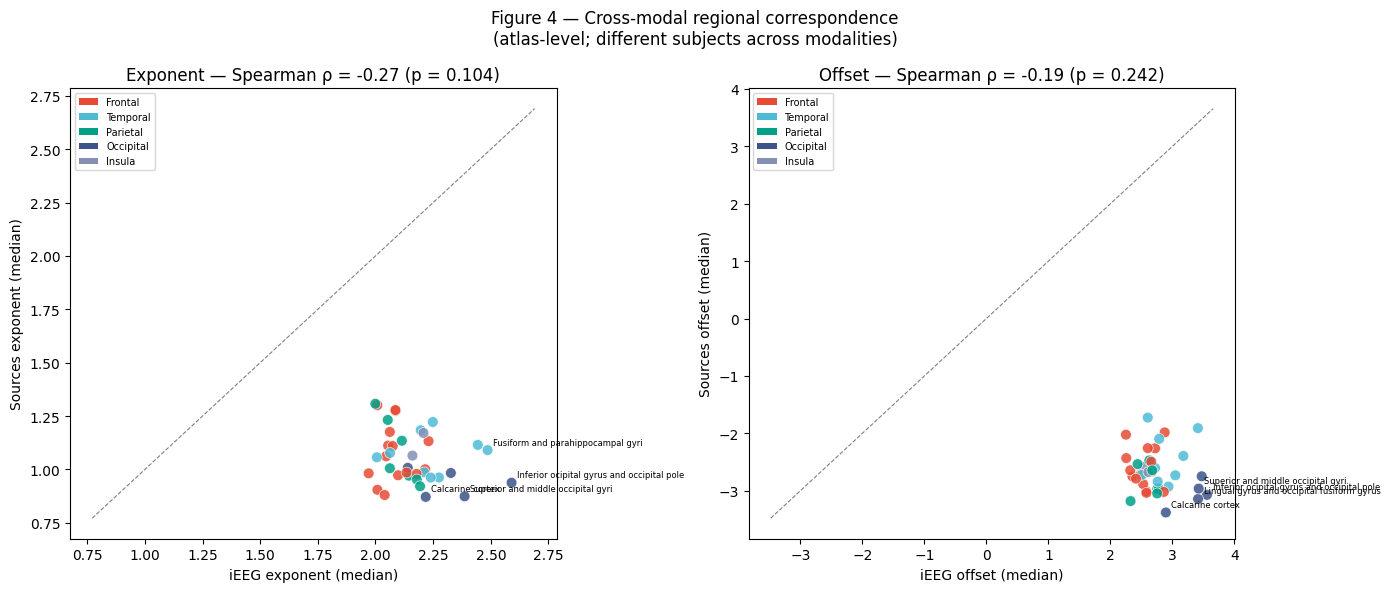

In [5]:
LOBE_COLORS = {
    "Frontal":   "#E64B35",
    "Temporal":  "#4DBBD5",
    "Parietal":  "#00A087",
    "Occipital": "#3C5488",
    "Limbic":    "#F39B7F",
    "Insula":    "#8491B4",
    "Other":     "#91D1C2",
}


def crossmodal_scatter(ax, x, y, labels, lobes, param, rho, p):
    colors = [LOBE_COLORS.get(str(l), LOBE_COLORS["Other"]) for l in lobes]
    ax.scatter(x, y, c=colors, s=60, alpha=0.85, edgecolors="white", linewidths=0.5)

    # Annotate regions that deviate most
    residuals = np.abs(y - x)
    top_idx   = np.argsort(residuals)[-4:]
    for i in top_idx:
        ax.annotate(
            labels[i], (x[i], y[i]),
            fontsize=6, xytext=(4, 4), textcoords="offset points"
        )

    # Unity line
    lims = [min(x.min(), y.min()) - 0.1, max(x.max(), y.max()) + 0.1]
    ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5, label="unity")

    ax.set_xlabel(f"iEEG {param} (median)")
    ax.set_ylabel(f"Sources {param} (median)")
    ax.set_title(f"{param.capitalize()} — Spearman ρ = {rho:.2f} (p = {p:.3f})")

    # Lobe legend
    legend_patches = [
        plt.Rectangle((0, 0), 1, 1, fc=c, label=lobe)
        for lobe, c in LOBE_COLORS.items()
        if lobe in lobes.values
    ]
    ax.legend(handles=legend_patches, fontsize=7, loc="upper left")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

crossmodal_scatter(
    ax1,
    x      = merged["exponent_median_ieeg"].values,
    y      = merged["exponent_median_sources"].values,
    labels = merged["Region name"].values,
    lobes  = merged["Lobe"],
    param  = "exponent",
    rho    = rho_exp, p = p_exp,
)

crossmodal_scatter(
    ax2,
    x      = merged["offset_median_ieeg"].values,
    y      = merged["offset_median_sources"].values,
    labels = merged["Region name"].values,
    lobes  = merged["Lobe"],
    param  = "offset",
    rho    = rho_off, p = p_off,
)

fig.suptitle("Figure 4 — Cross-modal regional correspondence\n"
             "(atlas-level; different subjects across modalities)",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_crossmodal_correspondence.svg", bbox_inches="tight", dpi=150)
plt.show()

## 4. Region-level correspondence table

Ranks regions by the absolute discrepancy between modalities.

In [6]:
table = merged[["Region name", "Lobe",
                "exponent_median_ieeg", "exponent_median_sources",
                "offset_median_ieeg",   "offset_median_sources"]].copy()

table["delta_exponent"] = table["exponent_median_sources"] - table["exponent_median_ieeg"]
table["delta_offset"]   = table["offset_median_sources"]   - table["offset_median_ieeg"]
table["abs_delta_exp"]  = table["delta_exponent"].abs()

print("Regions with largest exponent discrepancy (iEEG vs Sources):")
display(table.sort_values("abs_delta_exp", ascending=False).head(10).round(3))

print("\nRegions with smallest exponent discrepancy (best correspondence):")
display(table.sort_values("abs_delta_exp", ascending=True).head(10).round(3))

# Save
table.to_csv(INTERIM_DIR / "crossmodal_region_comparison.csv", index=False)
print("\nSaved crossmodal table.")

Regions with largest exponent discrepancy (iEEG vs Sources):


,Region name,Lobe,exponent_median_ieeg,exponent_median_sources,offset_median_ieeg,offset_median_sources,delta_exponent,delta_offset,abs_delta_exp
11,Inferior ocipital gyrus and occipital pole,Occipital,2.590,0.938,3.556,-3.071,-1.652,-6.627,1.652
29,Superior and middle occipital gyri,Occipital,2.386,0.874,3.423,-2.962,-1.512,-6.385,1.512
8,Fusiform and parahippocampal gyri,Temporal,2.486,1.091,3.176,-2.394,-1.395,-5.569,1.395
4,Calcarine cortex,Occipital,2.218,0.872,2.893,-3.378,-1.346,-6.271,1.346
13,Lingual gyrus and occipital fusiform gyrus,Occipital,2.327,0.984,3.413,-3.142,-1.343,-6.554,1.343
35,Temporal pole and planum polare,Temporal,2.444,1.115,2.786,-2.095,-1.329,-4.881,1.329
12,Inferior temporal gyrus,Temporal,2.275,0.963,2.935,-2.926,-1.313,-5.862,1.313
32,Superior temporal gyrus,Temporal,2.239,0.962,2.762,-2.840,-1.277,-5.602,1.277
34,Supramarginal gyrus,Parietal,2.193,0.921,2.753,-3.045,-1.272,-5.798,1.272
22,Parietal operculum,Parietal,2.179,0.953,2.324,-3.180,-1.226,-5.504,1.226



Regions with smallest exponent discrepancy (best correspondence):


,Region name,Lobe,exponent_median_ieeg,exponent_median_sources,offset_median_ieeg,offset_median_sources,delta_exponent,delta_offset,abs_delta_exp
25,Posterior cingulate,Parietal,1.999,1.308,2.438,-2.536,-0.692,-4.973,0.692
15,Medial segment of precentral gyrus,Frontal,2.008,1.301,2.720,-2.261,-0.707,-4.980,0.707
33,Supplementary motor cortex,Frontal,2.086,1.278,2.602,-2.257,-0.808,-4.859,0.808
17,Middle cingulate,Frontal,2.087,1.275,2.254,-2.431,-0.813,-4.685,0.813
28,Precuneus,Parietal,2.053,1.232,2.627,-2.472,-0.821,-5.099,0.821
30,Superior frontal gyrus and frontal pole,Frontal,2.062,1.176,2.658,-2.494,-0.886,-5.152,0.886
9,Gyrus rectus and orbital gyri,Frontal,2.055,1.112,2.874,-1.983,-0.943,-4.857,0.943
36,Transverse temporal gyrus,Temporal,2.006,1.057,3.046,-2.730,-0.949,-5.777,0.949
16,Medial segment of superior frontal gyrus,Frontal,2.075,1.110,2.528,-2.883,-0.965,-5.411,0.965
31,Superior parietal lobule,Parietal,2.114,1.135,2.675,-2.643,-0.980,-5.318,0.980



Saved crossmodal table.
